<a href="https://colab.research.google.com/github/yashikasgh/Food-Price-Prediction-/blob/main/experiment3/Experiment_3_EDA_Statistical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 3 — Exploratory Data Analysis & Statistical Analysis

### Aim
To perform exploratory data analysis and statistical analysis on the **cleaned dataset generated in Experiment 2** for the Essential Food Item Inflation Forecaster.

### Project context
The project studies retail prices of essential food commodities and detects inflation shocks defined as a **week-on-week price increase of at least 20%**. Experiment 3 focuses on understanding distributions, trends, relationships, possible outliers, and statistical significance before model development.

### Important
**Use the cleaned dataset from Experiment 2:** `cleaned_food_price_dataset.csv`.
Do not start EDA from the raw Excel file again unless the Experiment 2 cleaned CSV has not yet been generated.

## Objectives
1. Visualize the distribution of classes and numerical features.
2. Understand central tendency, spread, skewness, and possible outliers.
3. Study feature relationships using correlation analysis and heatmaps.
4. Fit an illustrative probability distribution to selected continuous/count variables.
5. Perform hypothesis tests such as **t-test, chi-square, and ANOVA** where appropriate.
6. Document the main EDA findings relevant to price forecasting and inflation-shock detection.

## Open-Source Tools
- **Pandas / NumPy** — data handling and numerical analysis
- **Matplotlib / Seaborn** — visualization
- **SciPy** — statistical tests and distribution fitting
- **Statsmodels** — descriptive/statistical utilities
- **Plotly** — optional interactive visualization

In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels plotly

In [2]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 1. Load the Cleaned Dataset

The cleaned CSV is the output of Experiment 2. It already contains the selected core commodity basket and the engineered time-series features such as lag, rolling mean, week-on-week percentage change, and shock labels for major shock-sensitive commodities.

In [3]:
CLEANED_FILE = "cleaned_food_price_dataset.csv"

if not os.path.exists(CLEANED_FILE):
    raise FileNotFoundError(
        f"{CLEANED_FILE} was not found. Run Experiment 2 first and generate the cleaned CSV."
    )

df = pd.read_csv(CLEANED_FILE)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (85, 47)


,Dates,States_UTs,source_sheet,Rice,Wheat,Atta_Wheat,Gram_Dal,Tur_Arhar_Dal,Urad_Dal,Moong_Dal,...,Onion_Lag2,Onion_RollingMean3,Onion_WoW_Pct,Onion_Shock,Tomato_Lag1,Tomato_Lag2,Tomato_RollingMean3,Tomato_WoW_Pct,Tomato_Shock,Any_Shock
0,2024-01-01,Maharashtra,2024 biweekly,49.53,39.95,43.42,82.53,165.95,127.63,123.68,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,0
1,2024-01-15,Maharashtra,2024 biweekly,49.79,40.42,43.58,81.47,162.37,128.37,122.53,...,NaN,NaN,-9.665763,0,31.370,NaN,NaN,-2.677718,0,0
2,2024-01-29,Maharashtra,2024 biweekly,50.47,40.37,43.42,81.84,160.89,128.37,122.42,...,33.21,30.176667,-8.933333,0,30.530,31.37,31.193333,3.766787,0,0
3,2024-02-12,Maharashtra,2024 biweekly,50.84,43.32,82.37,161.95,130.16,123.58,95.74,...,30.00,31.843333,39.860908,1,31.680,30.53,31.358333,0.583965,0,1
4,2024-02-26,Maharashtra,2024 biweekly,51.32,39.68,43.00,83.16,162.53,131.32,124.05,...,27.32,30.563333,-31.536247,0,31.865,31.68,31.865000,0.580574,0,0


In [5]:
# Standardize and inspect important columns.
df.columns = [str(c).strip() for c in df.columns]

DATE_COL = next((c for c in ["date", "Dates", "DATE"] if c in df.columns), None)
if DATE_COL is None:
    raise KeyError("Date column not found in the cleaned dataset.")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

CORE_COMMODITIES = [
    "Rice", "Wheat", "Atta (Wheat)",
    "Gram Dal", "Tur/Arhar Dal", "Urad Dal", "Moong Dal", "Masoor Dal",
    "Sugar", "Milk @", "Groundnut Oil (Packed)", "Mustard Oil (Packed)",
    "Vanaspati (Packed)", "Soya Oil (Packed)", "Sunflower Oil (Packed)",
    "Palm Oil (Packed)", "Gur", "Tea Loose", "Salt Pack (Iodised)",
    "Potato", "Onion", "Tomato"
]

# Keep only commodity columns actually present in the cleaned file.
CORE_COMMODITIES = [c for c in CORE_COMMODITIES if c in df.columns]
print("Core commodities found:", len(CORE_COMMODITIES))
print(CORE_COMMODITIES)

Core commodities found: 7
['Rice', 'Wheat', 'Sugar', 'Gur', 'Potato', 'Onion', 'Tomato']


## 2. Basic Data Overview

In [6]:
display(df.info())
display(df.describe(include="all").T)

print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Dates                 85 non-null     datetime64[ns]
 1   States_UTs            85 non-null     object        
 2   source_sheet          85 non-null     object        
 3   Rice                  85 non-null     float64       
 4   Wheat                 85 non-null     float64       
 5   Atta_Wheat            85 non-null     float64       
 6   Gram_Dal              85 non-null     float64       
 7   Tur_Arhar_Dal         85 non-null     float64       
 8   Urad_Dal              85 non-null     float64       
 9   Moong_Dal             85 non-null     float64       
 10  Masoor_Dal            85 non-null     float64       
 11  Sugar                 85 non-null     float64       
 12  Milk                  85 non-null     float64       
 13  Groundnut_Oil_Packed  

None

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Dates,85,NaN,NaN,NaN,2025-06-20 23:09:10.588235264,2024-01-01 00:00:00,2024-10-22 00:00:00,2025-07-30 00:00:00,2026-03-05 00:00:00,2026-07-30 00:00:00,NaN
States_UTs,85,1,Maharashtra,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_sheet,85,3,Jan-July 2026 weekly,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rice,85.0,NaN,NaN,NaN,47.473412,43.0,46.0,46.84,48.11,53.47,2.071423
Wheat,85.0,NaN,NaN,NaN,38.834824,36.89,37.63,38.63,39.37,48.5,1.769825
Atta_Wheat,85.0,NaN,NaN,NaN,44.825882,42.16,43.68,44.47,44.89,82.37,4.317778
Gram_Dal,85.0,NaN,NaN,NaN,89.008353,81.47,85.16,86.42,89.95,161.95,9.361582
Tur_Arhar_Dal,85.0,NaN,NaN,NaN,138.648353,114.53,125.0,127.32,162.37,178.89,20.963195
Urad_Dal,85.0,NaN,NaN,NaN,124.978,117.37,121.16,124.0,129.11,136.0,5.248997
Moong_Dal,85.0,NaN,NaN,NaN,117.873529,95.74,115.11,116.21,120.95,130.14,4.970845


Missing values: 18
Duplicate rows: 0
Date range: 2024-01-01 00:00:00 to 2026-07-30 00:00:00


## 3. Class Balance — Inflation Shock Distribution

Experiment 2 creates commodity-specific shock labels for Tomato, Onion, and Potato and an `Any_Shock` flag. The following plots show how balanced the shock class is.

,count
Any_Shock,
No Shock,77
Shock,8


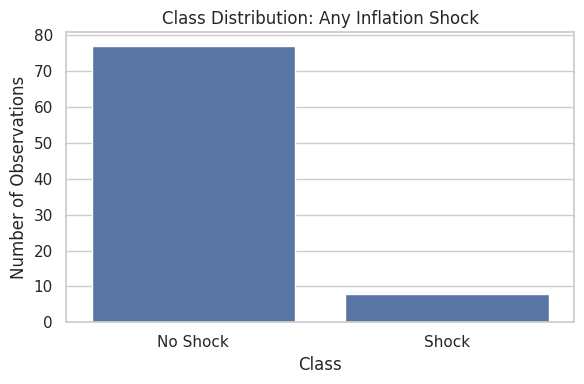

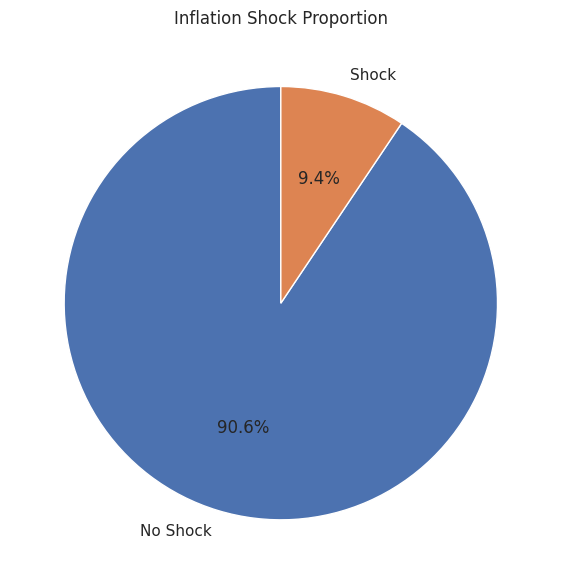

In [7]:
shock_cols = [
    c for c in df.columns
    if c.endswith("_Shock") and c != "Any_Shock"
]

if "Any_Shock" in df.columns:
    shock_summary = df["Any_Shock"].value_counts(dropna=False).sort_index()
    display(shock_summary.rename(index={0: "No Shock", 1: "Shock"}).to_frame("count"))

    plt.figure(figsize=(6, 4))
    sns.countplot(x=df["Any_Shock"].map({0: "No Shock", 1: "Shock"}))
    plt.title("Class Distribution: Any Inflation Shock")
    plt.xlabel("Class")
    plt.ylabel("Number of Observations")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    df["Any_Shock"].map({0: "No Shock", 1: "Shock"}).value_counts().plot.pie(
        autopct="%1.1f%%", startangle=90
    )
    plt.title("Inflation Shock Proportion")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Any_Shock column not found. Run the feature-engineering cell from Experiment 2 first.")

## 4. Descriptive Statistics and Central Tendency

For each core commodity, calculate mean, median, standard deviation, minimum, maximum, and coefficient of variation. The coefficient of variation helps compare relative variability across commodities with different price levels.

In [8]:
summary = pd.DataFrame({
    "mean": df[CORE_COMMODITIES].mean(),
    "median": df[CORE_COMMODITIES].median(),
    "std": df[CORE_COMMODITIES].std(),
    "min": df[CORE_COMMODITIES].min(),
    "max": df[CORE_COMMODITIES].max(),
    "skewness": df[CORE_COMMODITIES].skew(),
})
summary["cv_percent"] = (summary["std"] / summary["mean"]) * 100
summary = summary.sort_values("cv_percent", ascending=False)
display(summary.round(2))

,mean,median,std,min,max,skewness,cv_percent
Gur,60.40,57.05,26.33,53.53,295.89,8.75,43.59
Tomato,37.78,34.32,11.92,22.95,81.14,1.23,31.55
Onion,31.06,27.05,9.22,21.26,56.74,1.30,29.68
Potato,31.06,29.95,5.69,23.74,42.58,0.71,18.33
Sugar,44.54,44.26,2.42,42.37,58.95,4.07,5.43
Wheat,38.83,38.63,1.77,36.89,48.50,2.80,4.56
Rice,47.47,46.84,2.07,43.00,53.47,1.02,4.36


## 5. Frequency Distributions — Histograms

Histograms help identify concentration, skewness, multiple modes, and unusually large price values.

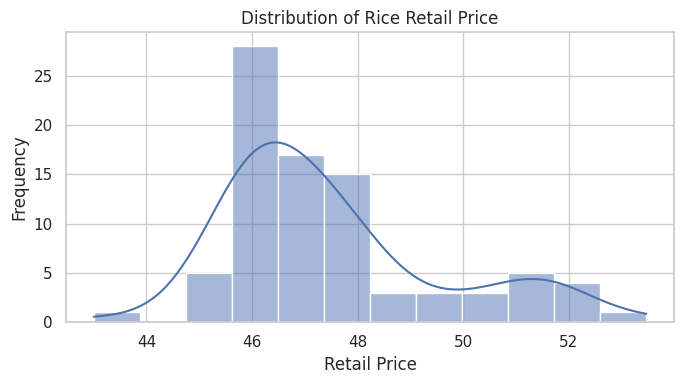

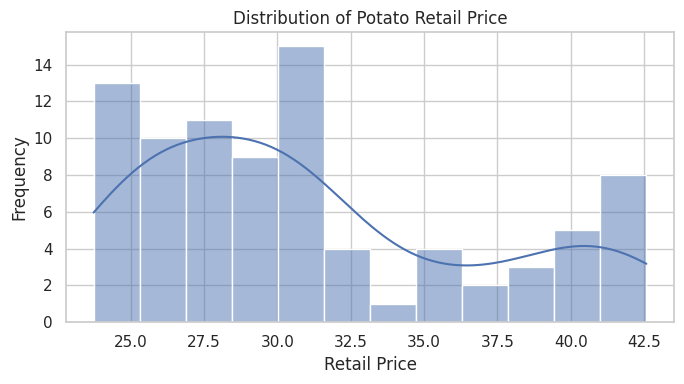

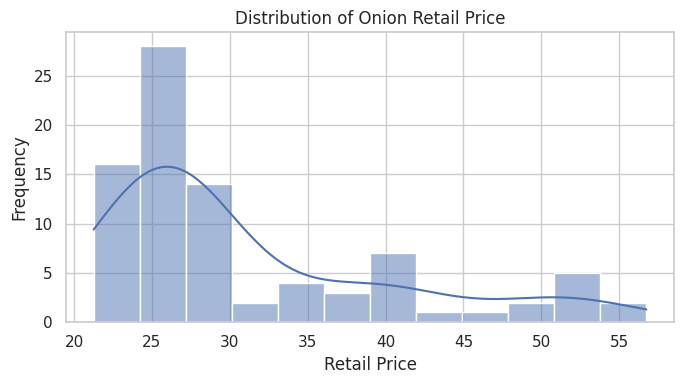

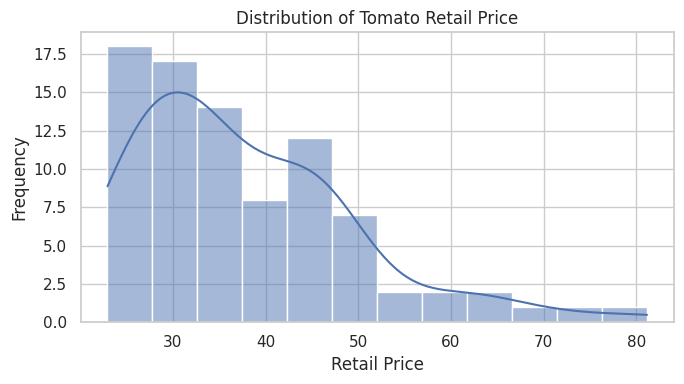

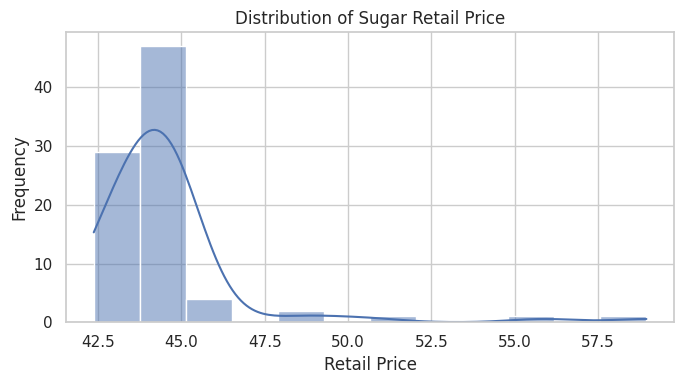

In [9]:
# Plot a manageable set of representative commodities.
PLOT_COMMODITIES = [c for c in ["Rice", "Potato", "Onion", "Tomato", "Sugar", "Groundnut Oil (Packed)"] if c in CORE_COMMODITIES]

for commodity in PLOT_COMMODITIES:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[commodity].dropna(), bins=12, kde=True)
    plt.title(f"Distribution of {commodity} Retail Price")
    plt.xlabel("Retail Price")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 6. Boxplots — Spread and Potential Outliers

Potential outliers are **inspected rather than automatically removed**, because genuine price spikes are important signals in this project.

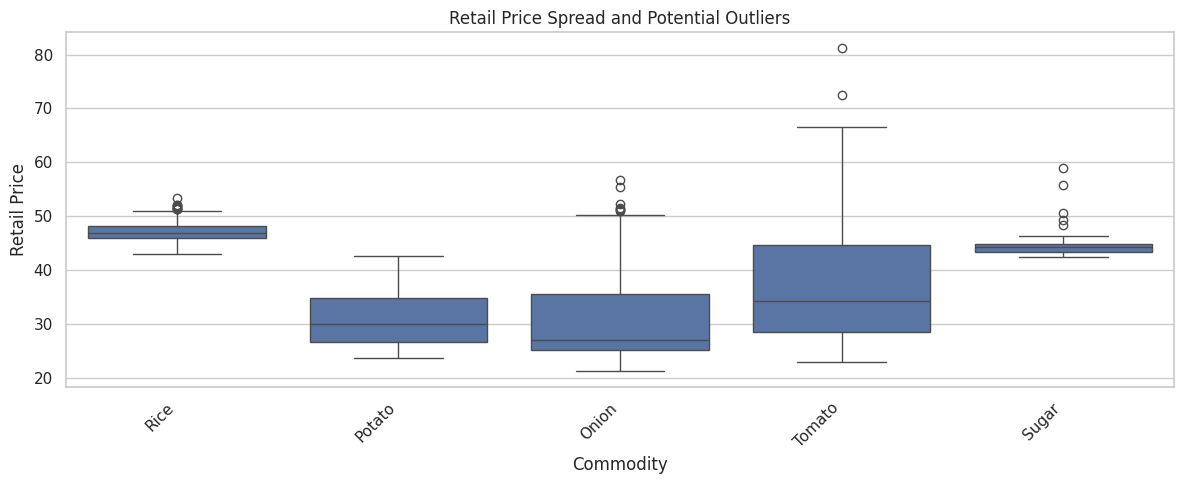

In [10]:
if PLOT_COMMODITIES:
    long_prices = df[PLOT_COMMODITIES].melt(var_name="Commodity", value_name="Retail Price")
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=long_prices, x="Commodity", y="Retail Price")
    plt.title("Retail Price Spread and Potential Outliers")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 7. Time-Series Trend Analysis

Price forecasting depends strongly on temporal behavior. The following charts compare selected commodity prices over time.

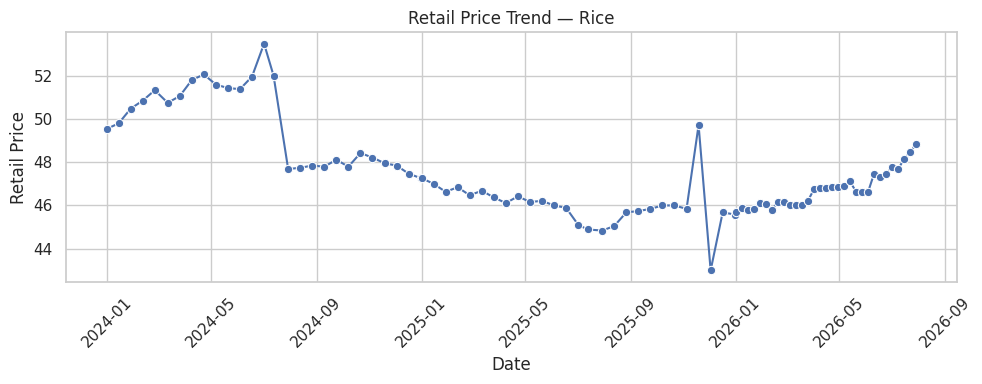

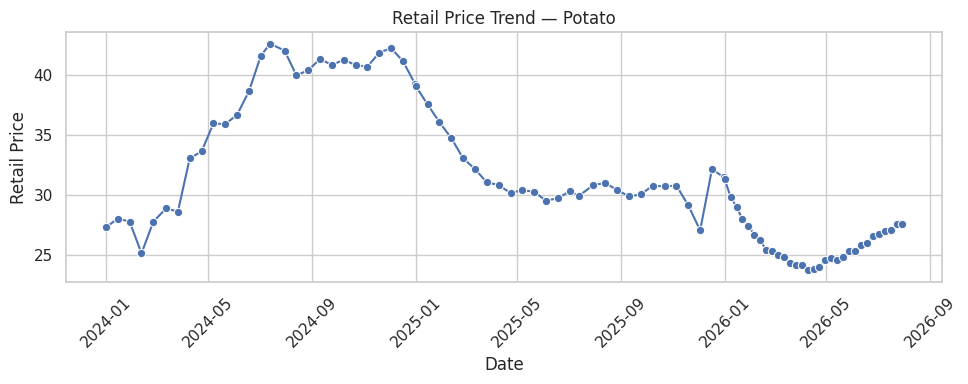

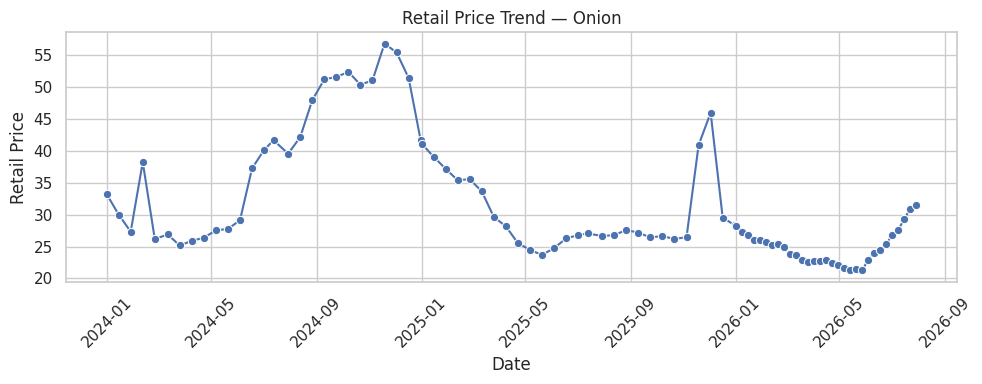

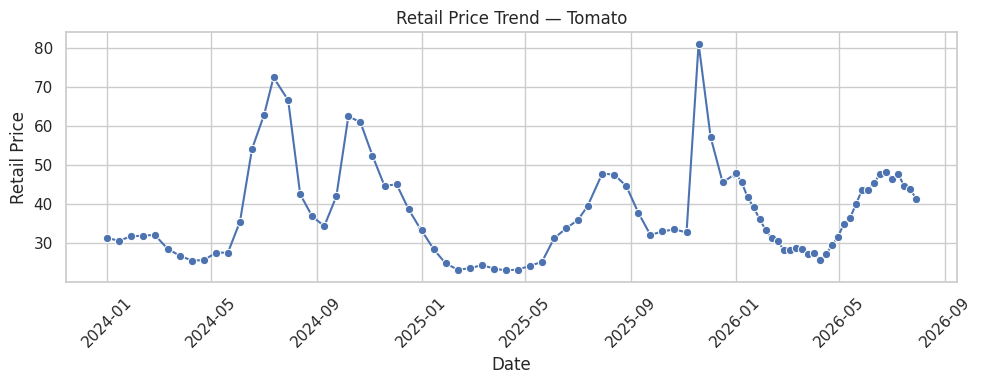

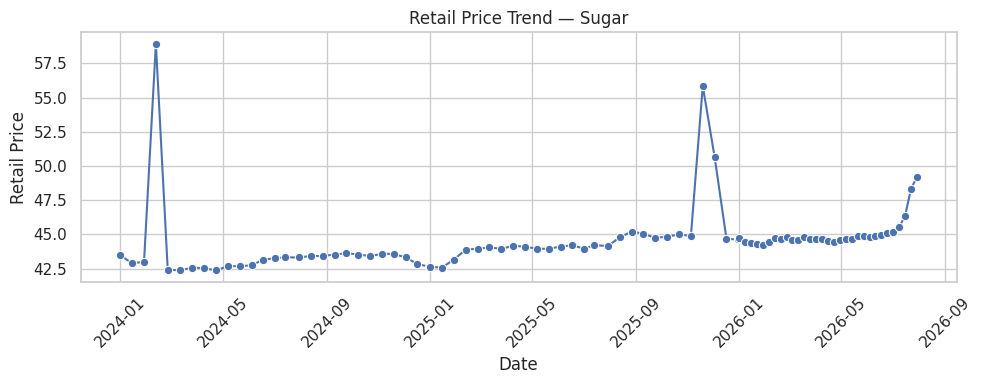

In [11]:
plot_df = df.sort_values(DATE_COL).copy()

for commodity in PLOT_COMMODITIES:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=plot_df, x=DATE_COL, y=commodity, marker="o")
    plt.title(f"Retail Price Trend — {commodity}")
    plt.xlabel("Date")
    plt.ylabel("Retail Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Correlation Analysis

Pearson correlation measures the strength of linear relationships between numerical variables. The heatmap is useful for identifying related commodities and redundant engineered features.

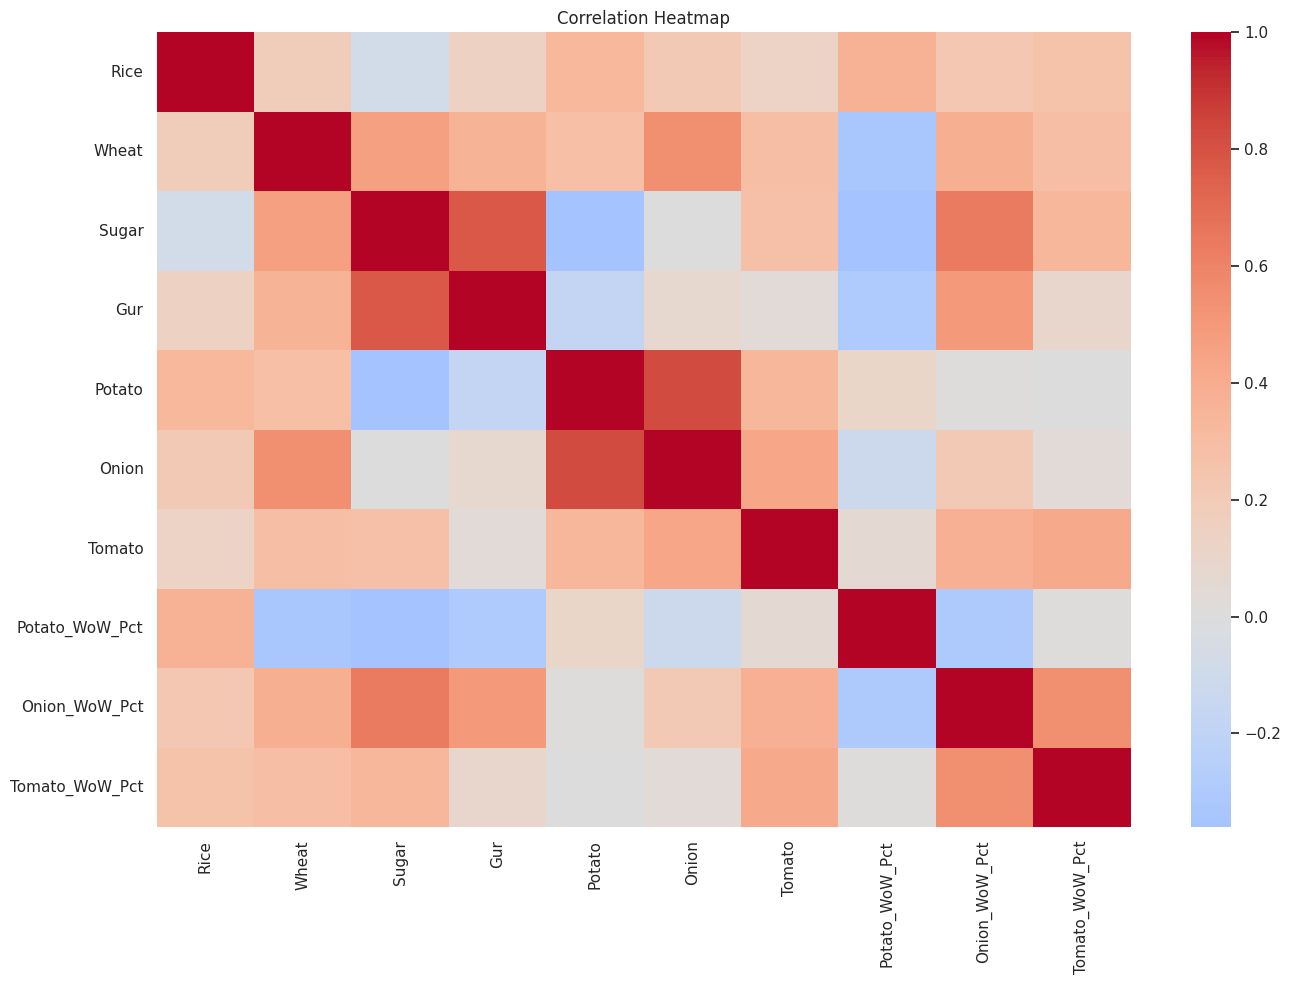

In [12]:
corr_columns = CORE_COMMODITIES.copy()

# Include selected engineered price-change features when available.
for c in df.columns:
    if c.endswith("_WoW_Pct") and c not in corr_columns:
        corr_columns.append(c)

corr = df[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 9. Distribution Fitting — Gaussian Model

Retail prices are continuous variables, so a Gaussian fit can be used as an **illustrative descriptive model**. The fitted curve is compared with the empirical histogram. A good visual fit does not imply that the data are truly normally distributed.

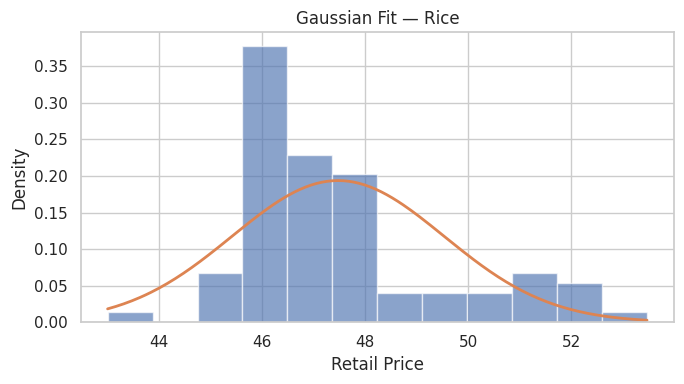

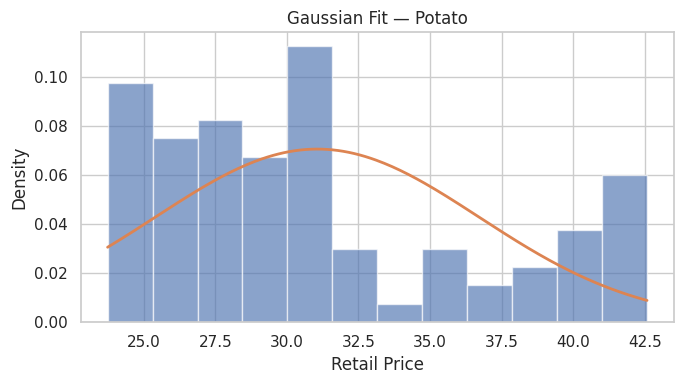

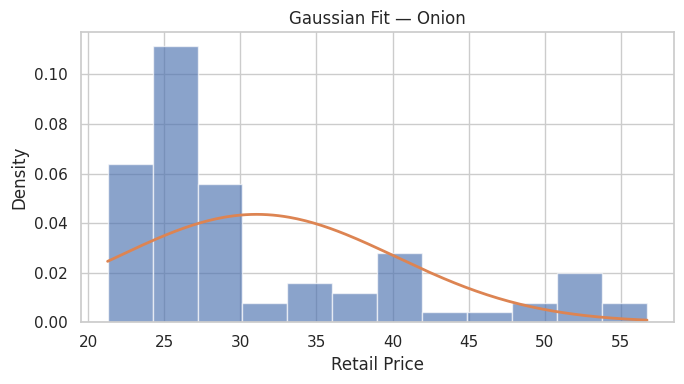

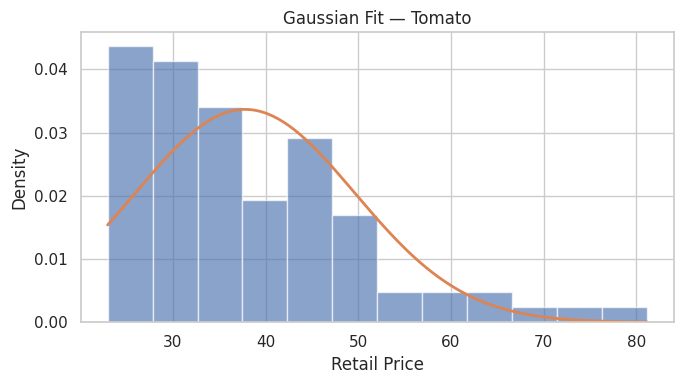

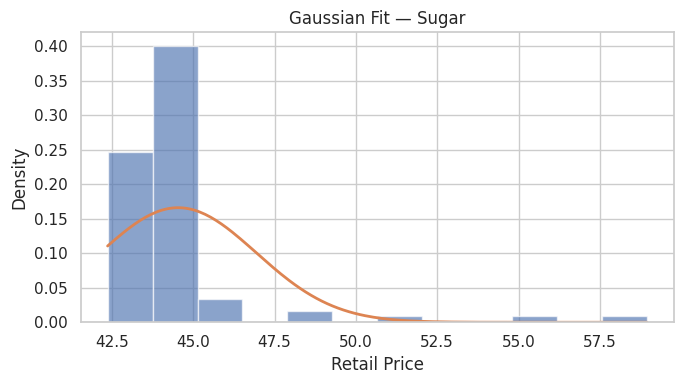

,commodity,fitted_mean,fitted_std
0,Rice,47.47,2.06
1,Potato,31.06,5.66
2,Onion,31.06,9.16
3,Tomato,37.78,11.85
4,Sugar,44.54,2.40


In [13]:
fit_results = []

for commodity in PLOT_COMMODITIES:
    x = df[commodity].dropna().astype(float)
    if len(x) < 5:
        continue
    mu, sigma = stats.norm.fit(x)
    fit_results.append([commodity, mu, sigma])

    xs = np.linspace(x.min(), x.max(), 200)
    pdf = stats.norm.pdf(xs, mu, sigma)

    plt.figure(figsize=(7, 4))
    plt.hist(x, bins=12, density=True, alpha=0.65)
    plt.plot(xs, pdf, linewidth=2)
    plt.title(f"Gaussian Fit — {commodity}")
    plt.xlabel("Retail Price")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

fit_table = pd.DataFrame(fit_results, columns=["commodity", "fitted_mean", "fitted_std"])
display(fit_table.round(2))

## 10. Hypothesis Testing

### General decision rule
- Significance level: **α = 0.05**
- If **p-value < 0.05**, reject the null hypothesis.
- Otherwise, fail to reject the null hypothesis.

Because the project dataset is a short historical time series and some groups are derived from the shock rule itself, these tests are treated as **exploratory evidence**, not causal proof.

### 10.1 Independent t-test — Shock vs Non-Shock Prices

For a selected shock-sensitive commodity (preferably Tomato), compare the mean price during shock observations with the mean price during non-shock observations.

**H₀:** Mean retail price is the same for shock and non-shock observations.  
**H₁:** Mean retail price differs between shock and non-shock observations.

In [14]:
# Select Tomato if available; otherwise use the first target commodity with a shock label.
test_commodity = None
for candidate in ["Tomato", "Onion", "Potato"]:
    if candidate in CORE_COMMODITIES:
        test_commodity = candidate
        break

if test_commodity is not None:
    safe = re.sub(r"[^A-Za-z0-9]+", "_", test_commodity).strip("_")
    wow_col = f"{safe}_WoW_Pct"
    shock_col = f"{safe}_Shock"

    if wow_col in df.columns and shock_col in df.columns:
        shock_prices = df.loc[df[shock_col] == 1, test_commodity].dropna()
        normal_prices = df.loc[df[shock_col] == 0, test_commodity].dropna()

        if len(shock_prices) >= 2 and len(normal_prices) >= 2:
            t_stat, p_value = ttest_ind(shock_prices, normal_prices, equal_var=False)
            print(f"Commodity: {test_commodity}")
            print("H0: Mean prices are equal for shock and non-shock observations.")
            print("H1: Mean prices are different for shock and non-shock observations.")
            print(f"Shock group size: {len(shock_prices)}")
            print(f"Non-shock group size: {len(normal_prices)}")
            print(f"Test statistic (t): {t_stat:.4f}")
            print(f"P-value: {p_value:.6f}")
            print("Interpretation:", "Reject H0." if p_value < 0.05 else "Fail to reject H0.")
        else:
            print("Not enough observations in both shock groups for a t-test.")
    else:
        print("Required WoW/shock columns were not found.")

Commodity: Tomato
H0: Mean prices are equal for shock and non-shock observations.
H1: Mean prices are different for shock and non-shock observations.
Shock group size: 7
Non-shock group size: 78
Test statistic (t): 2.1104
P-value: 0.076260
Interpretation: Fail to reject H0.


### 10.2 Chi-square Test — Commodity and Shock Occurrence

This test checks whether shock occurrence is independent of the selected commodity.

**H₀:** Shock occurrence is independent of commodity.  
**H₁:** Shock occurrence is associated with commodity.

In [15]:
commodity_shock_rows = []

for commodity in [c for c in ["Tomato", "Onion", "Potato"] if c in CORE_COMMODITIES]:
    safe = re.sub(r"[^A-Za-z0-9]+", "_", commodity).strip("_")
    shock_col = f"{safe}_Shock"
    if shock_col in df.columns:
        counts = df[shock_col].dropna().value_counts()
        commodity_shock_rows.append([
            commodity,
            int(counts.get(0, 0)),
            int(counts.get(1, 0))
        ])

if len(commodity_shock_rows) >= 2:
    contingency = pd.DataFrame(
        commodity_shock_rows,
        columns=["Commodity", "No_Shock", "Shock"]
    ).set_index("Commodity")
    display(contingency)

    chi2, p_value, dof, expected = chi2_contingency(contingency)
    print("H0: Shock occurrence is independent of commodity.")
    print("H1: Shock occurrence is associated with commodity.")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"P-value: {p_value:.6f}")
    print("Interpretation:", "Reject H0." if p_value < 0.05 else "Fail to reject H0.")
else:
    print("Not enough commodity-specific shock columns for chi-square test.")

,No_Shock,Shock
Commodity,,
Tomato,78,7
Onion,82,3
Potato,85,0


H0: Shock occurrence is independent of commodity.
H1: Shock occurrence is associated with commodity.
Chi-square statistic: 7.7020
Degrees of freedom: 2
P-value: 0.021258
Interpretation: Reject H0.


### 10.3 One-way ANOVA — Price Differences Across Calendar Quarters

To avoid directly comparing unrelated commodity price scales, ANOVA is applied to **one commodity across quarter groups**.

**H₀:** Mean retail price is equal across all quarters represented in the data.  
**H₁:** At least one quarter has a different mean retail price.

In [16]:
anova_commodity = test_commodity
if anova_commodity is not None and "Quarter" in df.columns:
    groups = [
        g[anova_commodity].dropna().values
        for _, g in df.assign(Quarter=df[DATE_COL].dt.quarter).groupby("Quarter")
        if len(g[anova_commodity].dropna()) >= 2
    ]
    quarters_present = [q for q, g in df.assign(Quarter=df[DATE_COL].dt.quarter).groupby("Quarter") if len(g[anova_commodity].dropna()) >= 2]

    if len(groups) >= 2:
        f_stat, p_value = f_oneway(*groups)
        print(f"Commodity: {anova_commodity}")
        print("H0: Mean price is equal across quarters.")
        print("H1: At least one quarter has a different mean price.")
        print(f"Quarters tested: {quarters_present}")
        print(f"F-statistic: {f_stat:.4f}")
        print(f"P-value: {p_value:.6f}")
        print("Interpretation:", "Reject H0." if p_value < 0.05 else "Fail to reject H0.")
    else:
        print("Not enough quarter groups for ANOVA.")

Commodity: Tomato
H0: Mean price is equal across quarters.
H1: At least one quarter has a different mean price.
Quarters tested: [1, 2, 3, 4]
F-statistic: 14.7482
P-value: 0.000000
Interpretation: Reject H0.


## 11. Optional Post-hoc Test — Tukey HSD

When ANOVA is significant, Tukey HSD can be used to identify which quarter pairs differ. It is included as an optional extension for completeness.

In [17]:
if anova_commodity is not None:
    tmp = df[[DATE_COL, anova_commodity]].dropna().copy()
    tmp["Quarter"] = tmp[DATE_COL].dt.quarter.astype(str)

    if tmp["Quarter"].nunique() >= 3 and len(tmp) >= 6:
        try:
            tukey = pairwise_tukeyhsd(
                endog=tmp[anova_commodity].values,
                groups=tmp["Quarter"].values,
                alpha=0.05
            )
            print(tukey)
        except Exception as e:
            print("Tukey HSD could not be calculated:", e)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   2.3764 0.8167  -4.731  9.4839  False
     1      3   14.502    0.0   6.834 22.1701   True
     1      4  16.6299    0.0  8.1963 25.0634   True
     2      3  12.1256 0.0006  4.3319 19.9193   True
     2      4  14.2535 0.0002  5.7055 22.8014   True
     3      4   2.1279 0.9258 -6.8916 11.1473  False
----------------------------------------------------


## 12. EDA Insights

The following cell produces a compact, data-driven summary that can be used in the experiment record. Review the values and write the final interpretation in the conclusion using the actual results produced by the notebook.

In [18]:
# Automatically identify highest variability and most skewed commodities.
if not summary.empty:
    highest_cv = summary["cv_percent"].idxmax()
    highest_skew = summary["skewness"].abs().idxmax()

    print("EDA INSIGHTS")
    print("-" * 50)
    print(f"1. Highest relative variability (CV): {highest_cv} ({summary.loc[highest_cv, 'cv_percent']:.2f}%).")
    print(f"2. Strongest absolute skewness: {highest_skew} (skewness = {summary.loc[highest_skew, 'skewness']:.2f}).")

    if "Any_Shock" in df.columns:
        shock_rate = df["Any_Shock"].mean() * 100
        print(f"3. Observed Any_Shock rate: {shock_rate:.2f}% of observations.")

    print("4. Boxplots and time-series plots should be checked for genuine price spikes before any outlier treatment.")
    print("5. Correlation heatmap indicates which commodities/features move together and may provide predictive information.")
    print("6. Statistical tests provide evidence of group differences/associations at the 5% significance level when p < 0.05.")

EDA INSIGHTS
--------------------------------------------------
1. Highest relative variability (CV): Gur (43.59%).
2. Strongest absolute skewness: Gur (skewness = 8.75).
3. Observed Any_Shock rate: 9.41% of observations.
4. Boxplots and time-series plots should be checked for genuine price spikes before any outlier treatment.
5. Correlation heatmap indicates which commodities/features move together and may provide predictive information.
6. Statistical tests provide evidence of group differences/associations at the 5% significance level when p < 0.05.


## 13. Summary of Hypothesis-Test Results

| Test | Null Hypothesis | Test Statistic | P-value | Decision | Interpretation |
|---|---|---:|---:|---|---|
| Independent t-test | Shock and non-shock mean prices are equal | Printed above | Printed above | Based on p < 0.05 | Exploratory group difference |
| Chi-square | Shock occurrence is independent of commodity | Printed above | Printed above | Based on p < 0.05 | Exploratory association |
| One-way ANOVA | Mean price is equal across quarters | Printed above | Printed above | Based on p < 0.05 | Exploratory temporal difference |

**Reporting rule:** explicitly state the test statistic, p-value, and whether H₀ is rejected or not rejected. Do not claim causation from these tests.

## 14. Inference

The cleaned dataset provides a consistent basis for exploratory analysis because missing-value handling, commodity selection, temporal ordering, and shock-feature construction were completed in Experiment 2. EDA reveals the central tendency and variability of essential commodity prices, highlights potential outliers and skewness, and shows temporal and cross-feature relationships. The statistical tests complement the visual analysis by checking whether selected differences or associations are statistically significant at the 5% level.

## 15. Conclusion

Exploratory Data Analysis and statistical analysis were performed on the cleaned essential food-price dataset. Histograms, boxplots, time-series plots, and correlation heatmaps were used to understand distributions, spread, temporal behavior, and feature relationships. Gaussian fitting provided an illustrative description of selected continuous price variables. Independent t-test, chi-square, and ANOVA were used for hypothesis testing, with decisions based on a significance level of 0.05. The findings provide a statistical foundation for the next stage of the project: **food-price forecasting and inflation-shock prediction**.